In [1]:
from sys import path
from pathlib import Path

ROOT = Path().resolve().parent
if str(ROOT) not in path:
    path.insert(0, str(ROOT))
    print(f"Added {ROOT} to sys.path")

Added /Users/surelmanda/Data-Science-Projects/SparkBatchTrainer to sys.path


In [2]:
import pprint
from utils.metrics import make_results_df
from utils.dataset_transform import preprocess_splits
from utils.plots import plot_confusion_valid_and_test
from utils.dataset_loader import get_dataset_path, load_dataset
from utils.dataset_preprocessor import to_spark_dfs, stop_spark_session, stratified_split_dataset

from spark_batch_trainer import CatBoostTrainer
from spark_batch_trainer import XGBoostTrainer
from spark_batch_trainer import LightGBMTrainer

## Loading the Binary Dataset (Diabetes)

In [4]:
print("\n" + "-"*60)
print('Load Big Binary Dataset (Diabetes)')
print("-"*60 + "\n")
dataset_path = get_dataset_path("data/big_binary_dataset")
big_df = load_dataset(dataset_path)

print(f"Loaded dataset: {dataset_path.name}, shape = {big_df.shape}")
display(big_df.head())

print("\n" + "-"*60)
print("Performing stratified split to divide dataset into training, validation, and test sets")
print("-"*60 + "\n")
target_column="diabetes"
train_df, valid_df, test_df = stratified_split_dataset(
    big_df,
    target_column=target_column,
    train_ratio=0.6,
    valid_ratio=0.2,
    test_ratio=0.2,
    shuffle=True,
    random_state=123
)
print("\n" + "-"*60)
print("Converting pandas DataFrames to Spark DataFrames...")
print("-"*60 + "\n")
spark_train_df, spark_valid_df = to_spark_dfs(train_df, valid_df)
print("Pandas DataFrames successfully converted to Spark DataFrames.")


------------------------------------------------------------
Load Big Binary Dataset (Diabetes)
------------------------------------------------------------

Loaded dataset: binary_diabetes_dataset.csv, shape = (100000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0



------------------------------------------------------------
Performing stratified split to divide dataset into training, validation, and test sets
------------------------------------------------------------

Dataset split results:
 - Train set: (60000, 9) → 60000 samples, 2 distinct classes
 - Valid set: (20000, 9) → 20000 samples, 2 distinct classes
 - Test set : (20000, 9) → 20000 samples, 2 distinct classes

------------------------------------------------------------
Converting pandas DataFrames to Spark DataFrames...
------------------------------------------------------------



Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
Exception in thread "main" java.nio.file.NoSuchFileException: /var/folders/yz/m36j329j0299mjsdn8nh6mb80000gn/T/tmpbjzpumbl/connection5969201536346381771.info
	at java.base/sun.nio.fs.UnixException.translateToIOException(UnixException.java:92)
	at java.base/sun.nio.fs.UnixException.rethrowAsIOException(UnixException.java:106)
	at java.base/sun.nio.fs.UnixException.rethrowAsIOException(UnixException.java:111)
	at java.base/sun.nio.fs.UnixFileSystemProvider.newByteChannel(UnixFileSystemProvider.java:218)
	at java.base/java.nio.file.Files.newByteChannel(Files.java:380)
	at ja

[SPARK] Conversion successful → Spark DataFrames created.


[SPARK] Train rows: 60000 | Validation rows: 20000
Pandas DataFrames successfully converted to Spark DataFrames.


In [ ]:
# Récupérer la session Spark active
spark = spark_train_df.sparkSession

# Stopper Spark
stop_spark_session(spark)

[SPARK] Stopping Spark session...
[SPARK] Session stopped successfully.


In [6]:
# ================================
# Chargement & split
# ================================
# Full preprocessing
splits, encoder = preprocess_splits(
    train_df,
    valid_df,
    test_df,
    target_column="diabetes",
    y_dtype="int",
    auto_encode_target=True,
)

print("Detected categorical columns:", splits.cat_cols)
print("Target classes:", encoder.classes_)
print("X_train shape:", splits.X_train.shape)

# Extract processed splits for convenience
X_train, y_train = splits.X_train, splits.y_train
X_valid, y_valid = splits.X_valid, splits.y_valid
X_test,  y_test  = splits.X_test,  splits.y_test
cat_cols         = splits.cat_cols



Detected categorical columns: ['gender', 'smoking_history']
Target classes: [0 1]
X_train shape: (60000, 8)


## 1. Model - XGBoost

2025-09-26 10:00:50,886 - spark_batch_trainer.core.base_trainer - INFO - Validating input parameters
2025-09-26 10:00:50,888 - spark_batch_trainer.core.base_trainer - INFO - Validating input parameters...
2025-09-26 10:00:50,888 - spark_batch_trainer.core.base_trainer - INFO - Input parameters validation passed.
2025-09-26 10:00:50,889 - spark_batch_trainer.core.base_trainer - INFO - Preparing training data
2025-09-26 10:00:50,889 - spark_batch_trainer.core.base_trainer - INFO - Preparing validation data
2025-09-26 10:00:50,890 - spark_batch_trainer.core.base_trainer - INFO - Converting Spark DataFrame to pandas DataFrame for validation.


Importing XGBoostTrainer...
XGBoostTrainer instantiated successfully
===== Configuration XGBoost =====
{'objective': 'binary:logistic',
 'eval_metric': 'logloss',
 'n_estimators': 50,
 'learning_rate': 0.05,
 'max_depth': 6,
 'reg_lambda': 3.0,
 'subsample': 0.8,
 'colsample_bytree': 0.8,
 'random_state': 42,
 'early_stopping_rounds': 50}

===== Configuration Training =====
{'num_batches': 5,
 'max_patience': 2,
 'show_learning_curve': True,
 'use_sample_weight': True,
 'verbose': False}

===== Configuration LR Scheduler =====
{'initial_lr': 0.1, 'decay_rate': 0.25, 'min_lr': 0.001}

Applying fit method...


2025-09-26 10:00:52,182 - spark_batch_trainer.core.base_trainer - INFO - Categorical features detected - Enabling categorical support for XGBoost model
2025-09-26 10:00:52,185 - spark_batch_trainer.core.memory_optimizer - INFO - === Starting memory optimization ===
2025-09-26 10:00:52,189 - spark_batch_trainer.core.memory_optimizer - INFO - Shape before optimization: (20000, 8)
2025-09-26 10:00:52,190 - spark_batch_trainer.core.memory_optimizer - INFO - Shape after optimization:  (20000, 8)
2025-09-26 10:00:52,190 - spark_batch_trainer.core.memory_optimizer - INFO - Memory before: 0.95 MB
2025-09-26 10:00:52,191 - spark_batch_trainer.core.memory_optimizer - INFO - Memory after:  0.50 MB
2025-09-26 10:00:52,191 - spark_batch_trainer.core.memory_optimizer - INFO - Memory reduced by: 0.46 MB
2025-09-26 10:00:52,192 - spark_batch_trainer.core.memory_optimizer - INFO - === Memory optimization finished ===
2025-09-26 10:00:52,192 - spark_batch_trainer.core.base_trainer - INFO - Setup trainin

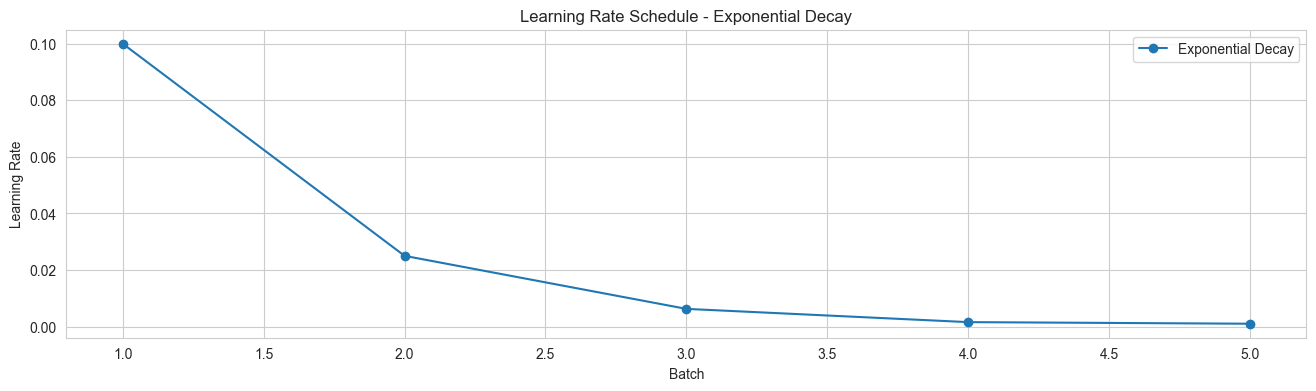

2025-09-26 10:00:59,908 - spark_batch_trainer.core.base_trainer - INFO - Plotting learning curve of XGBoost model...


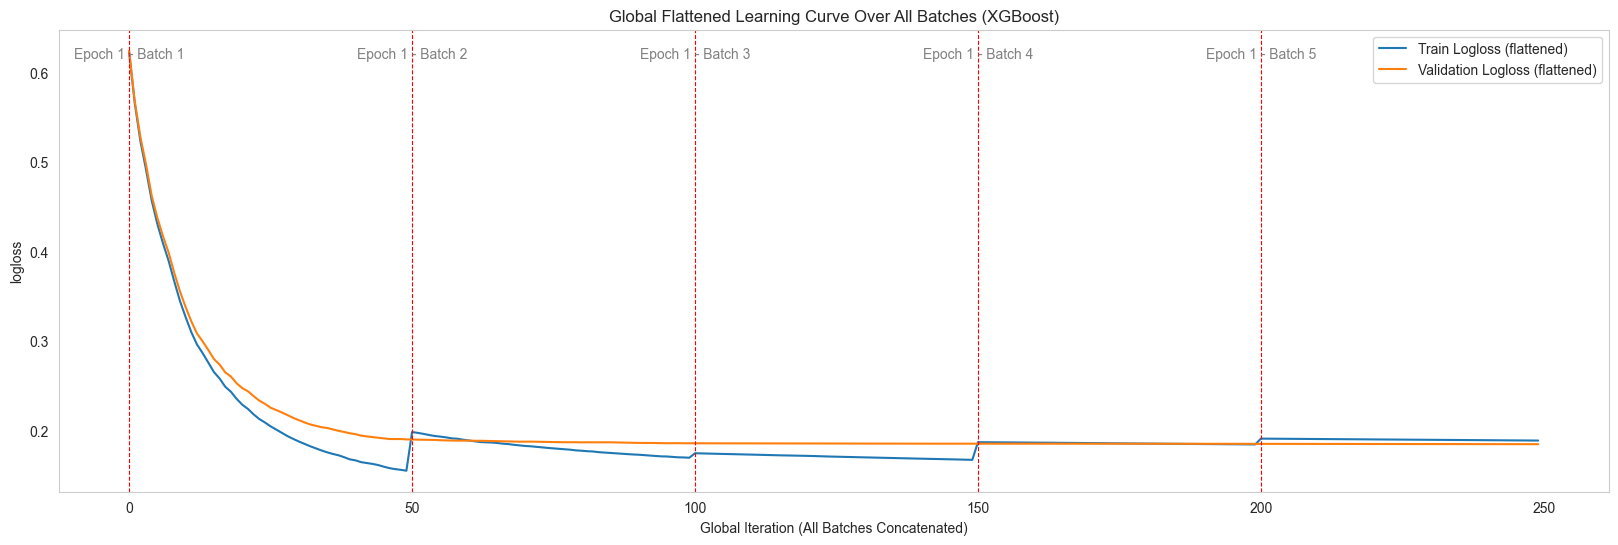

2025-09-26 10:01:00,012 - spark_batch_trainer.core.base_trainer - INFO - Learning curve plotted successfully.
2025-09-26 10:01:00,013 - spark_batch_trainer.core.base_trainer - INFO - XGBoost training completed
2025-09-26 10:01:00,013 - spark_batch_trainer.core.base_trainer - INFO - Total batches processed: 5
2025-09-26 10:01:00,014 - spark_batch_trainer.core.base_trainer - INFO - Best validation loss: 0.18452
2025-09-26 10:01:00,014 - spark_batch_trainer.core.base_trainer - INFO - Final model selected: best



   Evaluating the Trained Model



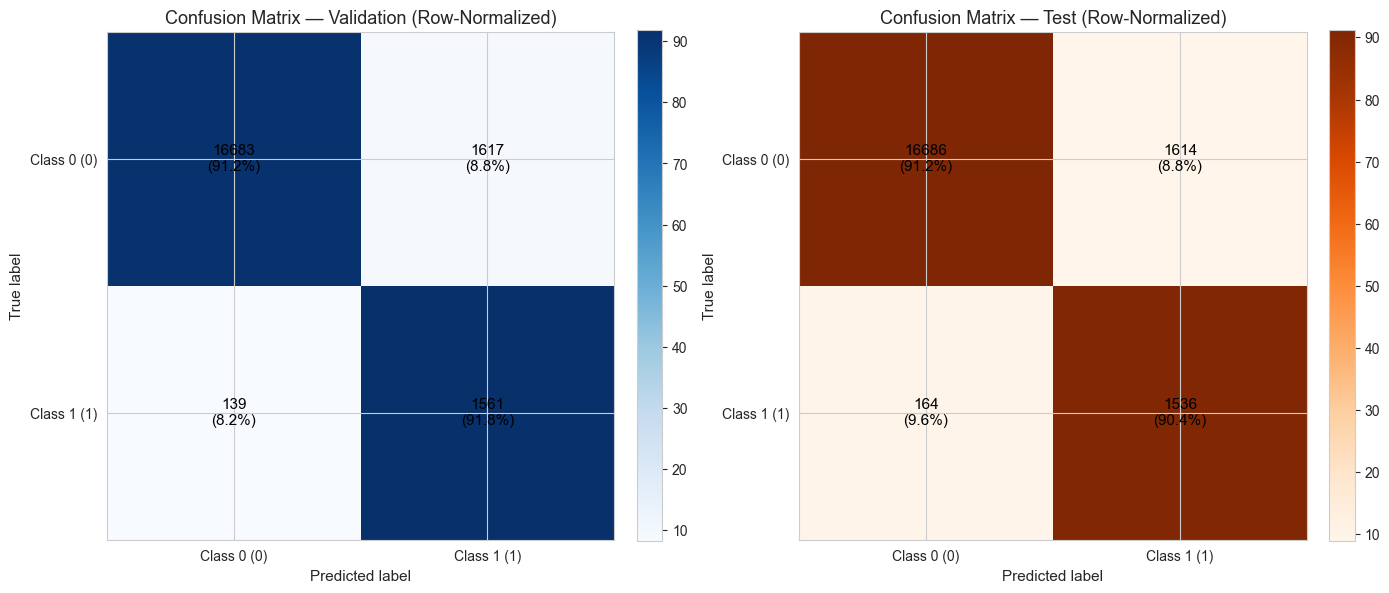

In [8]:
# ==================================================
# 1. Chargement & Configuration
# ==================================================
print("Importing XGBoostTrainer...")
trainer = XGBoostTrainer()
print("XGBoostTrainer instantiated successfully")

# Configuration du modèle (classification binaire)
config_model = {
    "objective": "binary:logistic",  # Classification binaire
    "eval_metric": "logloss",        # Peut aussi suivre ["auc", "logloss"]
    "n_estimators": 50,              # Nombre d’arbres
    "learning_rate": 0.05,           # Taux d’apprentissage
    "max_depth": 6,                  # Profondeur max
    "reg_lambda": 3.0,               # Régularisation L2
    "subsample": 0.8,                # Sous-échantillonnage des données
    "colsample_bytree": 0.8,         # Sous-échantillonnage des features
    "random_state": 42,              # Reproductibilité
    "early_stopping_rounds": 50,     # Early stopping via valid_set
    # "verbosity": 1,                 # Décommente si besoin de logs supplémentaires
}

# Scheduler du learning rate
config_lr_scheduler = {
    "initial_lr": 0.1,
    "decay_rate": 0.25,
    "min_lr": 1e-3,
}

# Entraînement batch-wise
config_training = {
    "num_batches": 5,               # Nombre de lots
    "max_patience": 2,              # Patience early stopping global
    "show_learning_curve": True,    # Afficher la courbe d’apprentissage
    "use_sample_weight": True,      # Prendre en compte les pondérations
    "verbose": False
}

print("===== Configuration XGBoost =====")
pprint.pprint(config_model, sort_dicts=False)
print("=================================\n")

print("===== Configuration Training =====")
pprint.pprint(config_training, sort_dicts=False)
print("=================================\n")

print("===== Configuration LR Scheduler =====")
pprint.pprint(config_lr_scheduler, sort_dicts=False)
print("=================================\n")


# ==================================================
# 2. Entraînement
# ==================================================
print("Applying fit method...")
trainer.fit(
    train_dataframe=spark_train_df,
    valid_dataframe=spark_valid_df,
    target_column=target_column,
    config_training=config_training,
    config_model=config_model,
    config_lr_scheduler=config_lr_scheduler,
)


# ==================================================
# 3. Évaluation
# ==================================================
print("\n" + "="*40)
print("   Evaluating the Trained Model")
print("="*40 + "\n")

# Récupération modèle entraîné
final_model = trainer.get_trained_model()

# Prédictions
y_pred_valid = final_model.predict(X_valid)
y_pred_test  = final_model.predict(X_test)

# Résultats sous forme DataFrame
results_valid_df = make_results_df(y_valid, y_pred_valid)
results_test_df  = make_results_df(y_test, y_pred_test)

# --------------------------------------------------
# Matrice de confusion
# --------------------------------------------------
plot_confusion_valid_and_test(
    results_valid_df,
    results_test_df,
    label_order=(0, 1),
    class_labels=("Class 0 (0)", "Class 1 (1)")
)


## 2. Model - Catboost

2025-09-26 10:02:24,776 - spark_batch_trainer.core.base_trainer - INFO - Validating input parameters
2025-09-26 10:02:24,779 - spark_batch_trainer.core.base_trainer - INFO - Validating input parameters...
2025-09-26 10:02:24,780 - spark_batch_trainer.core.base_trainer - INFO - Input parameters validation passed.
2025-09-26 10:02:24,781 - spark_batch_trainer.core.base_trainer - INFO - Preparing training data
2025-09-26 10:02:24,783 - spark_batch_trainer.core.base_trainer - INFO - Preparing validation data
2025-09-26 10:02:24,783 - spark_batch_trainer.core.base_trainer - INFO - Preparing validation data...
2025-09-26 10:02:24,785 - spark_batch_trainer.core.base_trainer - INFO - Converting Spark DataFrame to pandas DataFrame for validation.


Importing CatBoostTrainer...
CatBoostTrainer instantiated successfully
===== Configuration CatBoost =====
{'loss_function': 'Logloss',
 'eval_metric': 'Logloss',
 'iterations': 100,
 'learning_rate': 0.01,
 'depth': 6,
 'l2_leaf_reg': 3.0,
 'auto_class_weights': 'Balanced',
 'bootstrap_type': 'Bernoulli',
 'subsample': 0.8,
 'random_seed': 42,
 'verbose': False}

===== Configuration Training =====
{'num_batches': 5, 'max_patience': 3, 'show_learning_curve': True}

Applying fit method...


2025-09-26 10:02:25,751 - spark_batch_trainer.core.base_trainer - INFO - Categorical features detected in validation set
2025-09-26 10:02:25,753 - spark_batch_trainer.core.base_trainer - INFO - Number of categorical features identified: 2
2025-09-26 10:02:25,755 - spark_batch_trainer.core.base_trainer - INFO - Sample weights for validation set computed successfully
2025-09-26 10:02:25,755 - spark_batch_trainer.core.memory_optimizer - INFO - === Starting memory optimization ===
2025-09-26 10:02:25,759 - spark_batch_trainer.core.memory_optimizer - INFO - Shape before optimization: (20000, 8)
2025-09-26 10:02:25,759 - spark_batch_trainer.core.memory_optimizer - INFO - Shape after optimization:  (20000, 8)
2025-09-26 10:02:25,760 - spark_batch_trainer.core.memory_optimizer - INFO - Memory before: 0.95 MB
2025-09-26 10:02:25,761 - spark_batch_trainer.core.memory_optimizer - INFO - Memory after:  0.50 MB
2025-09-26 10:02:25,761 - spark_batch_trainer.core.memory_optimizer - INFO - Memory redu

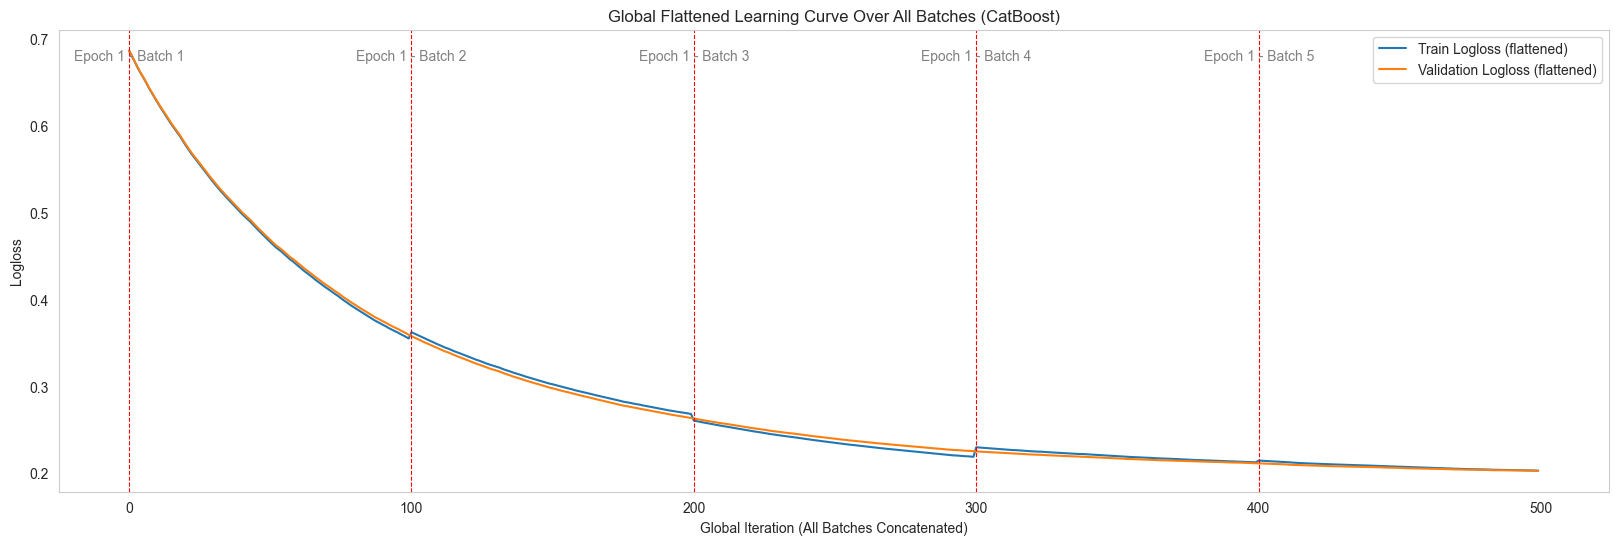

2025-09-26 10:02:35,284 - spark_batch_trainer.core.base_trainer - INFO - Learning curve plotted successfully.
2025-09-26 10:02:35,284 - spark_batch_trainer.core.base_trainer - INFO - CatBoost training completed successfully
2025-09-26 10:02:35,285 - spark_batch_trainer.core.base_trainer - INFO - Total batches processed: 5
2025-09-26 10:02:35,286 - spark_batch_trainer.core.base_trainer - INFO - Best validation loss: 0.20291
2025-09-26 10:02:35,286 - spark_batch_trainer.core.base_trainer - INFO - Final model selected: best
2025-09-26 10:02:35,286 - spark_batch_trainer.core.base_trainer - INFO - 🔖 Categorical features used: 2



   Evaluating the Trained Model



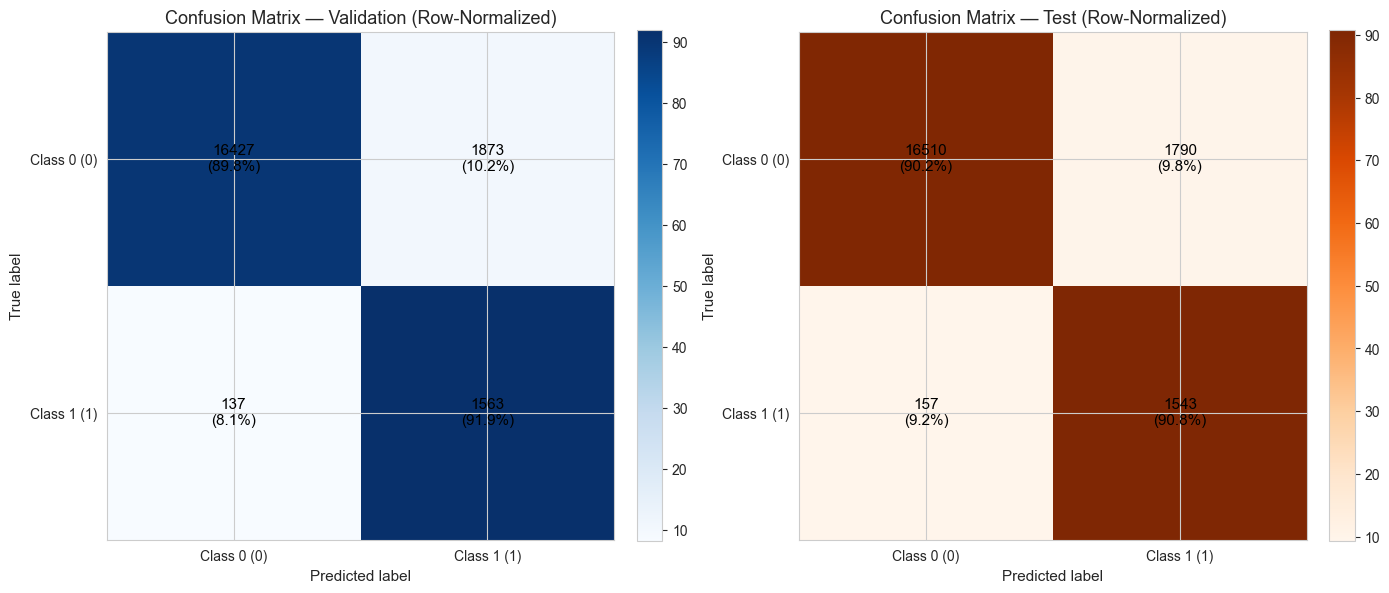

In [11]:
# ==================================================
# 1. Chargement & Configuration
# ==================================================
print("Importing CatBoostTrainer...")
trainer = CatBoostTrainer()
print("CatBoostTrainer instantiated successfully")

# Configuration modèle CatBoost (classification binaire)
config_model = {
    "loss_function": "Logloss",        # Fonction de perte binaire
    "eval_metric": "Logloss",          # Métrique d’évaluation
    "iterations": 100,                 # Nombre d’itérations
    "learning_rate": 0.01,             # Taux d’apprentissage
    "depth": 6,                        # Profondeur des arbres
    "l2_leaf_reg": 3.0,                # Régularisation L2
    "auto_class_weights": "Balanced",  # Gestion des classes déséquilibrées
    "bootstrap_type": "Bernoulli",     # Sous-échantillonnage
    "subsample": 0.8,                  # Ratio de données par arbre
    "random_seed": 42,                 # Reproductibilité
    "verbose": False,                  # Pas de logs détaillés
    # "early_stopping_rounds": 10,     # Peut être activé si nécessaire
}

# Configuration entraînement batch-wise
config_training = {
    "num_batches": 5,               # Nombre de lots
    "max_patience": 3,               # Patience early stopping global
    "show_learning_curve": True,     # Afficher la courbe d’apprentissage
}

print("===== Configuration CatBoost =====")
pprint.pprint(config_model, sort_dicts=False)
print("=================================\n")

print("===== Configuration Training =====")
pprint.pprint(config_training, sort_dicts=False)
print("=================================\n")


# ==================================================
# 2. Entraînement
# ==================================================
print("Applying fit method...")
trainer.fit(
    train_dataframe=spark_train_df,
    valid_dataframe=spark_valid_df,
    target_column=target_column,
    config_training=config_training,
    config_model=config_model,
)


# ==================================================
# 3. Évaluation
# ==================================================
print("\n" + "="*40)
print("   Evaluating the Trained Model")
print("="*40 + "\n")

# Récupération du modèle entraîné
final_model = trainer.get_trained_model()

# Prédictions
y_pred_valid = final_model.predict(X_valid)
y_pred_test  = final_model.predict(X_test)

# Résultats sous forme DataFrame
results_valid_df = make_results_df(y_valid, y_pred_valid)
results_test_df  = make_results_df(y_test, y_pred_test)

# --------------------------------------------------
# Matrice de confusion
# --------------------------------------------------
plot_confusion_valid_and_test(
    results_valid_df,
    results_test_df,
    label_order=(0, 1),
    class_labels=("Class 0 (0)", "Class 1 (1)")
)

## 3. Model - LGBMClassifier

2025-09-26 10:22:21,838 - spark_batch_trainer.core.base_trainer - INFO - Validating input parameters...
2025-09-26 10:22:21,842 - spark_batch_trainer.core.base_trainer - INFO - Input parameters validation passed.
2025-09-26 10:22:21,844 - spark_batch_trainer.core.base_trainer - INFO - Preparing validation data...
2025-09-26 10:22:21,845 - spark_batch_trainer.core.base_trainer - INFO - Converting Spark DataFrame to pandas DataFrame for validation.


Loading LightGBMTrainer module...
LightGBMTrainer instantiated successfully
===== Configuration LightGBM =====
{'objective': 'binary',
 'n_estimators': 50,
 'num_leaves': 30,
 'random_state': 42,
 'force_col_wise': True}

===== Configuration Training =====
{'num_batches': 5,
 'max_patience': 2,
 'eval_metric': 'binary_logloss',
 'show_learning_curve': True,
 'use_sample_weight': True,
 'verbose': False}

===== Configuration LR Scheduler =====
{'initial_lr': 0.1, 'decay_rate': 0.25, 'min_lr': 0.001}

Applying fit method...


2025-09-26 10:22:23,231 - spark_batch_trainer.core.base_trainer - INFO - Categorical features detected in validation set
2025-09-26 10:22:23,233 - spark_batch_trainer.core.base_trainer - INFO - Number of categorical features identified: 2
2025-09-26 10:22:23,234 - spark_batch_trainer.core.base_trainer - INFO - Sample weights for validation set computed successfully
2025-09-26 10:22:23,235 - spark_batch_trainer.core.memory_optimizer - INFO - === Starting memory optimization ===
2025-09-26 10:22:23,242 - spark_batch_trainer.core.memory_optimizer - INFO - Shape before optimization: (20000, 8)
2025-09-26 10:22:23,242 - spark_batch_trainer.core.memory_optimizer - INFO - Shape after optimization:  (20000, 8)
2025-09-26 10:22:23,243 - spark_batch_trainer.core.memory_optimizer - INFO - Memory before: 0.95 MB
2025-09-26 10:22:23,243 - spark_batch_trainer.core.memory_optimizer - INFO - Memory after:  0.50 MB
2025-09-26 10:22:23,243 - spark_batch_trainer.core.memory_optimizer - INFO - Memory redu

[LightGBM] [Info] Number of positive: 1020, number of negative: 10980
[LightGBM] [Info] Total Bins 410
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


2025-09-26 10:22:25,210 - spark_batch_trainer.core.base_trainer - INFO - 🎯 Completed LGBM training on batch 1
2025-09-26 10:22:25,210 - spark_batch_trainer.core.base_trainer - INFO - 🔍 Evaluating LightGBM model on batch 1
2025-09-26 10:22:25,213 - spark_batch_trainer.core.base_trainer - INFO - Tracking evaluation metric: binary_logloss
2025-09-26 10:22:25,214 - spark_batch_trainer.core.base_trainer - INFO - Batch 1 - binary_logloss | Train: 0.10261 | Valid: 0.21682
2025-09-26 10:22:25,214 - spark_batch_trainer.core.base_trainer - INFO - 🎉 New best model found - binary_logloss: 0.21682 (improvement: inf)
2025-09-26 10:22:25,217 - spark_batch_trainer.core.base_trainer - INFO - Filtering batch 2/5
2025-09-26 10:22:25,238 - spark_batch_trainer.core.base_trainer - INFO - Converting Spark DataFrame to pandas DataFrame for batch 2/5
2025-09-26 10:22:26,718 - spark_batch_trainer.core.base_trainer - INFO -        
--- 📦 Processing batch 2/5 ---
2025-09-26 10:22:26,719 - spark_batch_trainer.core

...

2025-09-26 10:22:29,483 - spark_batch_trainer.core.base_trainer - INFO - 🎯 Completed LGBM training on batch 3
2025-09-26 10:22:29,483 - spark_batch_trainer.core.base_trainer - INFO - 🔍 Evaluating LightGBM model on batch 3
2025-09-26 10:22:29,488 - spark_batch_trainer.core.base_trainer - INFO - Tracking evaluation metric: binary_logloss
2025-09-26 10:22:29,489 - spark_batch_trainer.core.base_trainer - INFO - Batch 3 - binary_logloss | Train: 0.16263 | Valid: 0.20429
2025-09-26 10:22:29,489 - spark_batch_trainer.core.base_trainer - INFO - 🎉 New best model found - binary_logloss: 0.20429 (improvement: 0.00013)
2025-09-26 10:22:29,495 - spark_batch_trainer.core.base_trainer - INFO - Filtering batch 4/5
2025-09-26 10:22:29,535 - spark_batch_trainer.core.base_trainer - INFO - Converting Spark DataFrame to pandas DataFrame for batch 4/5
2025-09-26 10:22:30,968 - spark_batch_trainer.core.base_trainer - INFO -        
--- 📦 Processing batch 4/5 ---
2025-09-26 10:22:30,969 - spark_batch_trainer.

[LightGBM] [Info] Number of positive: 1020, number of negative: 10980
[LightGBM] [Info] Total Bins 410
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 8


2025-09-26 10:22:31,424 - spark_batch_trainer.core.base_trainer - INFO - 🎯 Completed LGBM training on batch 4
2025-09-26 10:22:31,425 - spark_batch_trainer.core.base_trainer - INFO - 🔍 Evaluating LightGBM model on batch 4
2025-09-26 10:22:31,431 - spark_batch_trainer.core.base_trainer - INFO - Tracking evaluation metric: binary_logloss
2025-09-26 10:22:31,431 - spark_batch_trainer.core.base_trainer - INFO - Batch 4 - binary_logloss | Train: 0.19254 | Valid: 0.20353
2025-09-26 10:22:31,432 - spark_batch_trainer.core.base_trainer - INFO - 🎉 New best model found - binary_logloss: 0.20353 (improvement: 0.00077)
2025-09-26 10:22:31,441 - spark_batch_trainer.core.base_trainer - INFO - Filtering batch 5/5
2025-09-26 10:22:31,478 - spark_batch_trainer.core.base_trainer - INFO - Converting Spark DataFrame to pandas DataFrame for batch 5/5
2025-09-26 10:22:33,064 - spark_batch_trainer.core.base_trainer - INFO -        
--- 📦 Processing batch 5/5 ---
2025-09-26 10:22:33,065 - spark_batch_trainer.

[LightGBM] [Info] Number of positive: 1020, number of negative: 10980
[LightGBM] [Info] Total Bins 409
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 8


2025-09-26 10:22:33,497 - spark_batch_trainer.core.base_trainer - INFO - 🎯 Completed LGBM training on batch 5
2025-09-26 10:22:33,498 - spark_batch_trainer.core.base_trainer - INFO - 🔍 Evaluating LightGBM model on batch 5
2025-09-26 10:22:33,505 - spark_batch_trainer.core.base_trainer - INFO - Tracking evaluation metric: binary_logloss
2025-09-26 10:22:33,505 - spark_batch_trainer.core.base_trainer - INFO - Batch 5 - binary_logloss | Train: 0.19912 | Valid: 0.20285
2025-09-26 10:22:33,506 - spark_batch_trainer.core.base_trainer - INFO - 🎉 New best model found - binary_logloss: 0.20285 (improvement: 0.00067)
2025-09-26 10:22:33,518 - spark_batch_trainer.core.base_trainer - INFO - Cleaning cache of OptimizedWeightCalculator
2025-09-26 10:22:33,518 - spark_batch_trainer.core.base_trainer - INFO - Plotting learning-rate schedule (scheduler=Exponential Decay, n_points=5)


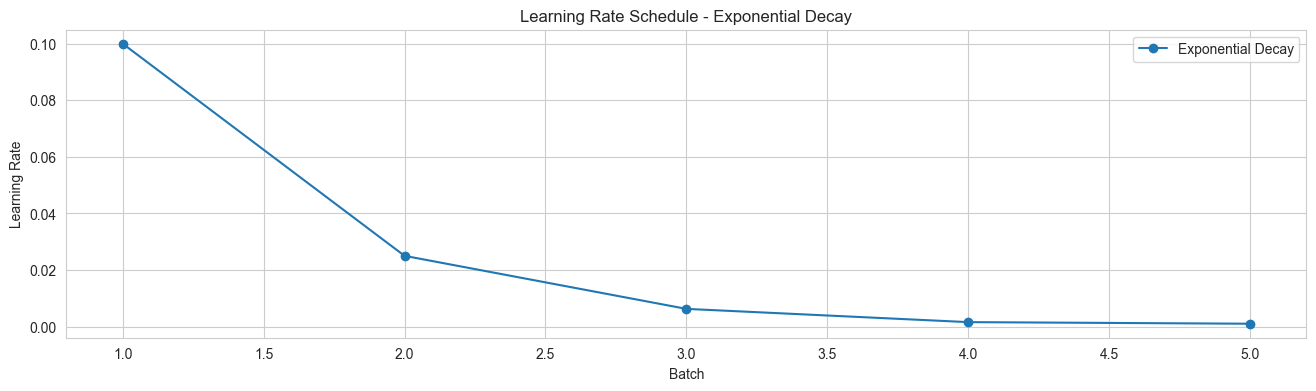

2025-09-26 10:22:33,632 - spark_batch_trainer.core.base_trainer - INFO - Plotting learning curve of LGBM model...


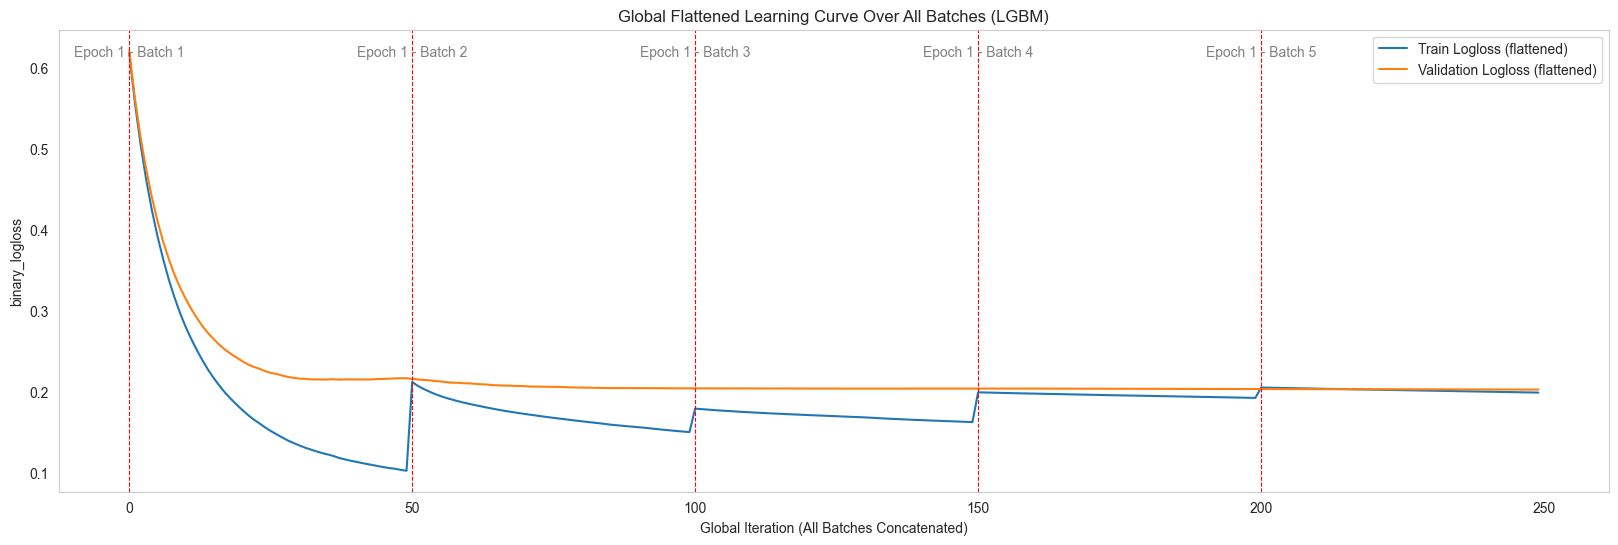

2025-09-26 10:22:33,813 - spark_batch_trainer.core.base_trainer - INFO - Learning curve plotted successfully.
2025-09-26 10:22:33,814 - spark_batch_trainer.core.base_trainer - INFO - LGBM training completed successfully
2025-09-26 10:22:33,815 - spark_batch_trainer.core.base_trainer - INFO - Total batches processed: 5
2025-09-26 10:22:33,815 - spark_batch_trainer.core.base_trainer - INFO - Best validation loss: 0.20285
2025-09-26 10:22:33,816 - spark_batch_trainer.core.base_trainer - INFO - Final model selected: best
2025-09-26 10:22:33,816 - spark_batch_trainer.core.base_trainer - INFO - Categorical features used: 2



   Evaluating the Trained Model



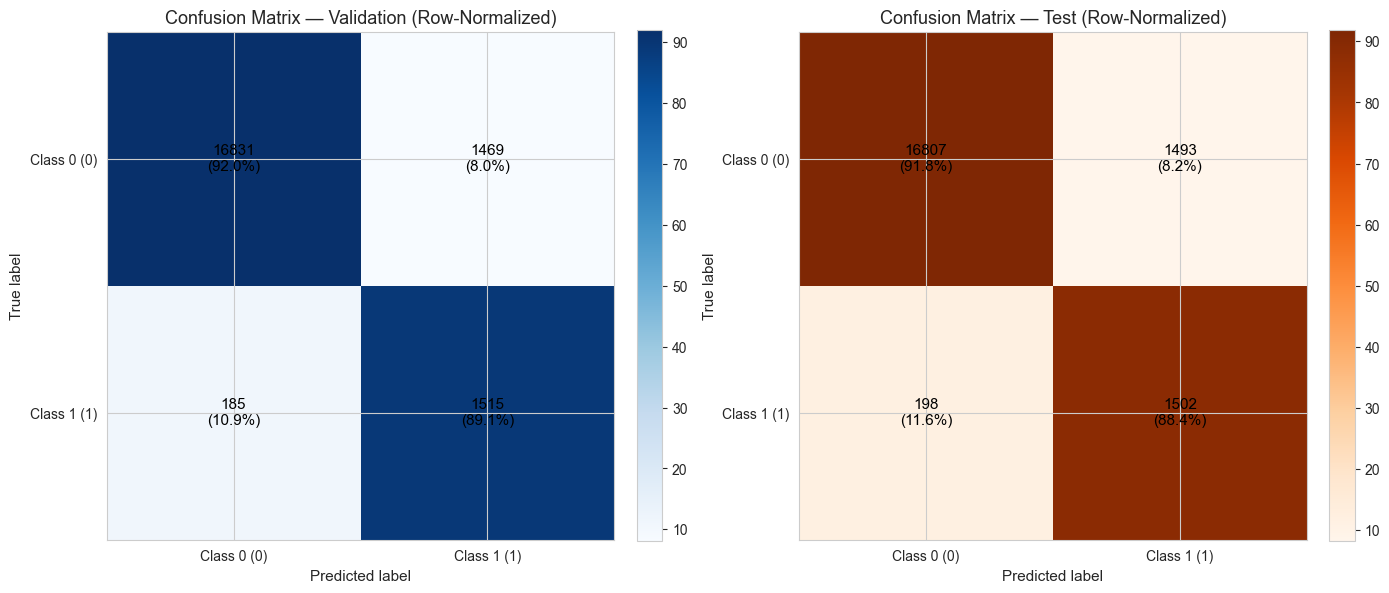

In [8]:
# ==================================================
# 1. Chargement & Configuration
# ==================================================
print("Loading LightGBMTrainer module...")
trainer = LightGBMTrainer()  # Wrapper lightgbm.LGBMClassifier
print("LightGBMTrainer instantiated successfully")

# Configuration modèle LightGBM (classification binaire)
config_model = {
    "objective": "binary",         # Classification binaire
    "n_estimators": 50,            # Nombre d’arbres
    "num_leaves": 30,              # Nombre de feuilles max
    "random_state": 42,            # Reproductibilité
    "force_col_wise": True,        # Optimisation mémoire
    # "learning_rate": 0.05,       # Décommente si besoin
    # "max_depth": 6,              # Décommente si besoin
    # "reg_lambda": 3.0,           # Décommente si besoin
    # "subsample": 0.8,            # Décommente si besoin
    # "colsample_bytree": 0.8,     # Décommente si besoin
    # "early_stopping_rounds": 10, # Géré via valid_set
}

# Scheduler du learning rate
config_lr_scheduler = {
    "initial_lr": 0.1,
    "decay_rate": 0.25,
    "min_lr": 1e-3,
}

# Entraînement batch-wise
config_training = {
    "num_batches": 5,               # Nombre de lots
    "max_patience": 2,              # Patience early stopping global
    "eval_metric": "binary_logloss",# Métrique d’évaluation
    "show_learning_curve": True,    # Afficher la courbe d’apprentissage
    "use_sample_weight": True,      # Pondération des échantillons
    "verbose":False,
}

print("===== Configuration LightGBM =====")
pprint.pprint(config_model, sort_dicts=False)
print("=================================\n")

print("===== Configuration Training =====")
pprint.pprint(config_training, sort_dicts=False)
print("=================================\n")

print("===== Configuration LR Scheduler =====")
pprint.pprint(config_lr_scheduler, sort_dicts=False)
print("=================================\n")


# ==================================================
# 2. Entraînement
# ==================================================
print("Applying fit method...")
trainer.fit(
    train_dataframe=spark_train_df,
    valid_dataframe=spark_valid_df,
    target_column=target_column,
    config_training=config_training,
    config_model=config_model,
    config_lr_scheduler=config_lr_scheduler,
)


# ==================================================
# 3. Évaluation
# ==================================================
print("\n" + "="*40)
print("   Evaluating the Trained Model")
print("="*40 + "\n")

# Récupération du modèle entraîné
final_model = trainer.get_trained_model()

# Prédictions
y_pred_valid = final_model.predict(X_valid)
y_pred_test  = final_model.predict(X_test)

# Résultats sous forme DataFrame
results_valid_df = make_results_df(y_valid, y_pred_valid)
results_test_df  = make_results_df(y_test, y_pred_test)

# --------------------------------------------------
# Matrice de confusion
# --------------------------------------------------
plot_confusion_valid_and_test(
    results_valid_df,
    results_test_df,
    label_order=(0, 1),
    class_labels=("Class 0 (0)", "Class 1 (1)")
)


In [9]:
# Récupérer la session Spark active
spark = spark_train_df.sparkSession

# Stopper Spark
stop_spark_session(spark)

[SPARK] Stopping Spark session...
[SPARK] Session stopped successfully.
